# 1. Data Loading and Cleaning

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Melbourne = pd.read_csv("data/MelbourneJune.csv").copy()
Sydney = pd.read_csv("data/SydneyJune.csv").copy()
Brisbane = pd.read_csv("data/BrisbaneJune.csv").copy()
Tasmania = pd.read_csv("data/TasmaniaJune.csv").copy()
WesternAustralia = pd.read_csv("data/WesternAustraliaJune.csv").copy()

In [ ]:
major_cities = [Melbourne, Sydney, Brisbane, Tasmania, WesternAustralia]
drop_cols = ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_url', 
             'host_name', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_is_superhost', 'host_picture_url', 
             'host_thumbnail_url', 'host_neighbourhood', 'host_total_listings_count', 'host_has_profile_pic', 'neighbourhood', 'neighbourhood_group_cleansed',
            'property_type', 'amenities', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights'
            'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_last_scraped', 'number_of_reviews_ltm', 'host_identity_verified', 
            'number_of_reviews_l30d', 'has_availability', 'availability_eoy', 'first_review', 'calculated_host_listings_count_entire_homes',
            'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'host_acceptance_rate',
            'reviews_per_month', 'estimated_revenue_l365d', 'license', 'review_scores_accuracy', 'review_scores_cleanliness',
            'review_scores_checkin', 'review_scores_communication', 'review_scores_value', 'last_review', 'bathrooms_text']

for city in major_cities:
    city.dropna(axis = 1, how = 'all', inplace = True) #  Drop columns where EVERY ("ALL") values are missing and edit the dataset 
    city.drop(columns = drop_cols, inplace = True, errors = 'ignore') # Drop columns that are not useful for our analysis
    city['price'] = city['price'].str.replace('$', '').str.replace(',', '').astype(float) # Convert price from string to float for numerical analysis and visualisation
    city.dropna(subset = ['price'], inplace = True) # Drop rows for listings where price does not exists
    city['estimated_revenue'] = city['price'] * city['estimated_occupancy_l365d'] # Estimate revenue for each listing for later comparisons and visualisations


    missing_counts = city.isna().sum()

    if 'bedrooms' in city.columns and missing_counts.get('bedrooms', 0) > 100: # There are a lot of missing values in the "bedrooms" column, so we will infer the value from the "accommodates" column divided by 2 (assuming an average of 2 guests per bedroom)
        city['bedrooms'] = city['bedrooms'].fillna(city['accommodates'] // 2) # Impute missing values in the "bedrooms" column by filling them with the value from the "accommodates" column divided by 2 (assuming an average of 2 guests per bedroom)

    if 'beds' in city.columns and missing_counts.get('beds', 0) > 100: 
        city['beds'] = city['beds'].fillna(city['accommodates'] // 2)

    if 'bathrooms' in city.columns and missing_counts.get('bathrooms', 0) > 100: #  Calculate the normal number of bathrooms for each bedroom count and fill the holes with that number.      
        city['bathrooms'] = city['bathrooms'].fillna(city.groupby('bedrooms')['bathrooms'].transform('median'))

After removing duplicate and insignificant columns from our city datasets, we observed remaining missing values in key areas such as review_scores for location and ratings, host dates, bedrooms and bathrooms counts. It was not sensible to correct these missing data by filling in the values with 0, as it is both factually introduce and can introduce significant bias into our analysis. Therefore, we have chosen to retain these as Na/NaN values and will utilise functions that automatically exclude them during aggregation or analysis to maintain accuracy. The missing bedrooms and bathrooms values have been dealt with by calculating similar listings with same number of bedrooms and bathrooms and using the median or inferring from the accommodates column to ensure that our estimations remain realistic. Additionally, listings without a price have been removed from our analysis.

# Exploratory Data Analysis

### Price Distribution 

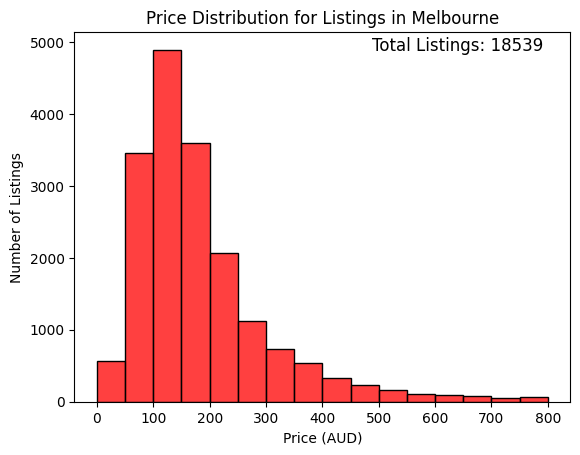

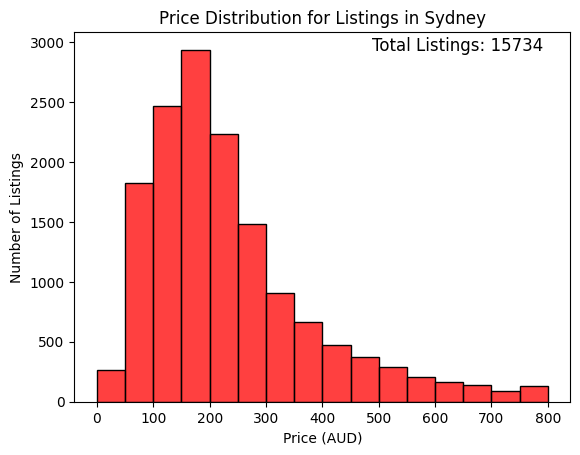

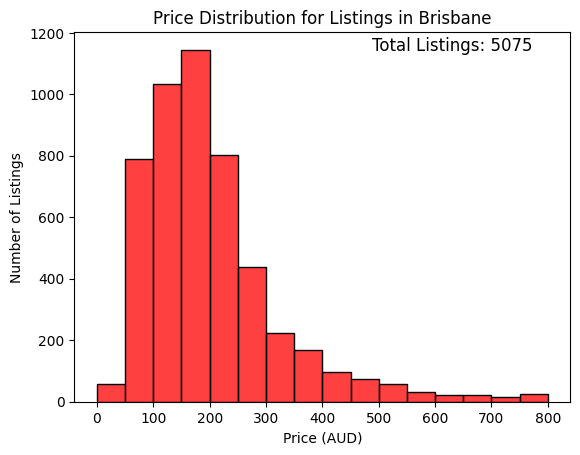

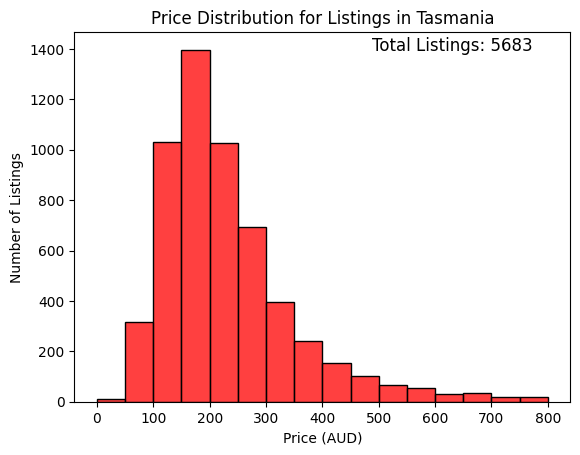

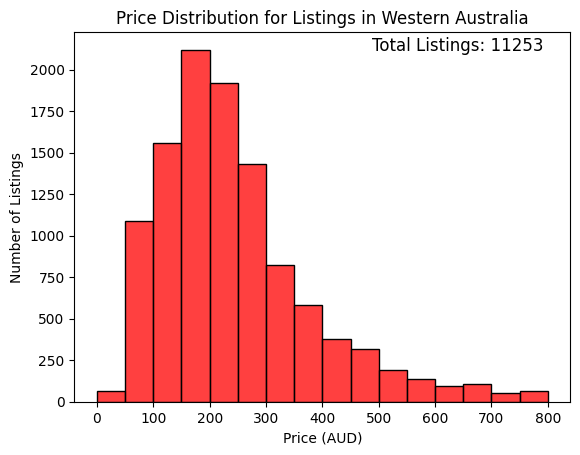

In [43]:
major_cities = {"Melbourne": Melbourne, "Sydney": Sydney, "Brisbane": Brisbane, "Tasmania": Tasmania, "Western Australia": WesternAustralia}

for city_name, city in major_cities.items():
    sns.histplot(data = city, x = 'price', binrange = (0, 800), binwidth = 50, color = "red")
    plt.title("Price Distribution for Listings in " + city_name)
    plt.xlabel("Price (AUD)")
    plt.ylabel("Number of Listings")
    plt.text(0.6, 0.95, 'Total Listings: ' + str(len(city)), fontsize = 12, transform=plt.gca().transAxes)
    plt.show()  

The price distribution across all five cities show a clear and consistent right-skewed pattern, with the majority of listings priced between $50 and $300 per night. Notably, Sydney, Brisbane, Western Australia and Tasmania all share a mode bracket of $150 to $200, while Melbourne sits lower at $100 to $150. Melbourne's lower mode is particular interesting given that it has the highest listing volume of all regions, having around 17% more than Sydney. This combination of a higher supply and lower mode in listing price could be from several reasons, for example greater competitiveness, weaker tourism or a stronger local preference for hotel accommodation. As expected, there are outlier prices in each city, with listing prices above $600 per night, which appear more frequently in Sydney and, more surprisingly, Western Australia.